### 1. Import the libraries

#### 1.1. Import the needed libraries

In [1]:
from utils.data_loader import DatasetLoader
from utils.data_visualization import DataVisualization
from utils.preprocessing import Preprocessor
from utils.feature_selection import MutualInformation
from utils.models import ensemble_models
from utils.model_evaluator import ModelEvaluator
from utils.tree_shap import SHAPTreeExplainer
import pandas as pd

import warnings
warnings.filterwarnings('ignore')


#### 1.2. Define the global variables 

In [2]:
binary_target = 'label' 
multiclass_target = 'type' 
all_target_columns = [binary_target, multiclass_target]
columns_to_drop = ["src_ip", "src_port", "dst_ip", "dst_port", "dns_query", "ssl_subject", "ssl_issuer", "http_uri", "http_user_agent"] 
categorical_missing_token = '-'
numeric_imputation_strategy = 'median'
categorical_imputation_strategy = 'most_frequent'
shuffle=True
random_state=80


### 2. Load the dataset

In [3]:
ton_iot_loader = DatasetLoader(dataset_name="TON_IoT")

df= ton_iot_loader.load()
df = ton_iot_loader.remove_duplicates(df)
df

Duplicated rows: 20569
Dataframe shape: (190474, 44)


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_query,dns_qclass,dns_qtype,dns_rcode,dns_AA,dns_RD,dns_RA,dns_rejected,ssl_version,ssl_cipher,ssl_resumed,ssl_established,ssl_subject,ssl_issuer,http_trans_depth,http_method,http_uri,http_version,http_request_body_len,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,0,108,108064,31,3832,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,0,1,48,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,0,1,52,1,40,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,backdoor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190469,192.168.1.32,48286,176.28.50.165,80,tcp,http,65.376610,2665,322,S3,0,5,2925,5,590,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,xss
190470,192.168.1.32,48288,176.28.50.165,80,tcp,http,65.710346,1987,322,S3,0,6,2307,5,590,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,xss
190471,192.168.1.32,48292,176.28.50.165,80,tcp,http,65.766512,3922,322,S3,0,7,4294,6,642,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,xss
190472,192.168.1.32,48294,176.28.50.165,80,tcp,http,65.753940,2401,322,S3,0,6,2721,5,590,-,0,0,0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0,0,0,-,-,-,-,-,-,1,xss


### 3. Data Exploration

#### 3.1. Basic Data Analysis

In [4]:
ton_iot_loader.info(df)

,Datatype,Not nulls,Nulls,% Nulls,Unique cnt,Mean,StDev,Min,Q25,Q50,Q75,Max
src_ip,object,190474,0,0.0,51,NaN,NaN,NaN,NaN,NaN,NaN,NaN
src_port,int64,190474,0,0.0,26628,39755.028098,1.880899e+04,1.0,35650.000000,45729.500000,52042.750000,6.552800e+04
dst_ip,object,190474,0,0.0,753,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dst_port,int64,190474,0,0.0,2039,2136.147989,6.971551e+03,0.0,53.000000,80.000000,445.000000,6.546700e+04
proto,object,190474,0,0.0,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service,object,190474,0,0.0,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,float64,190474,0,0.0,68570,8.532477,5.938158e+02,0.0,0.000009,0.000391,0.136369,9.351693e+04
src_bytes,int64,190474,0,0.0,2199,285986.833878,1.799405e+07,0.0,0.000000,0.000000,130.000000,3.890855e+09
dst_bytes,int64,190474,0,0.0,2338,286752.486948,1.897376e+07,0.0,0.000000,0.000000,178.000000,3.913853e+09
conn_state,object,190474,0,0.0,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### 3.2. Target Features

In [7]:
viz = DataVisualization(
    df,
    label_columns=all_target_columns
)

##### 3.2.1. Binary class

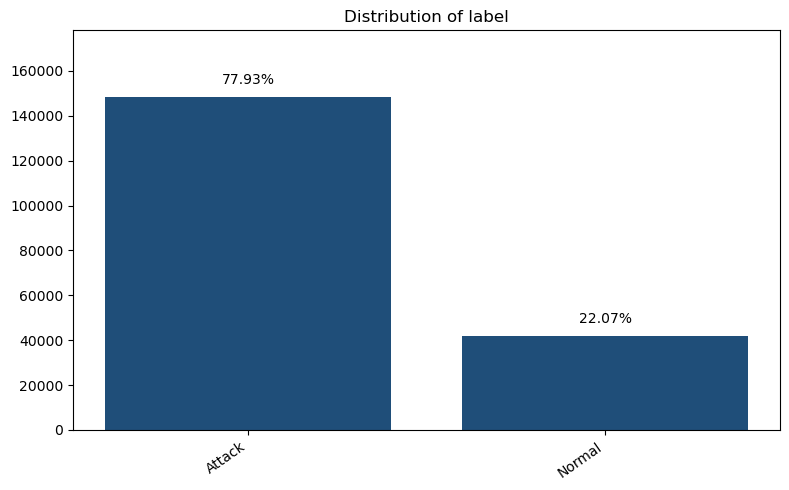

In [8]:
viz.target_distribution(
    label_column=binary_target,
    label_mapping={1: "Attack", 0: "Normal"}
)


##### 3.2.2. Multiclass

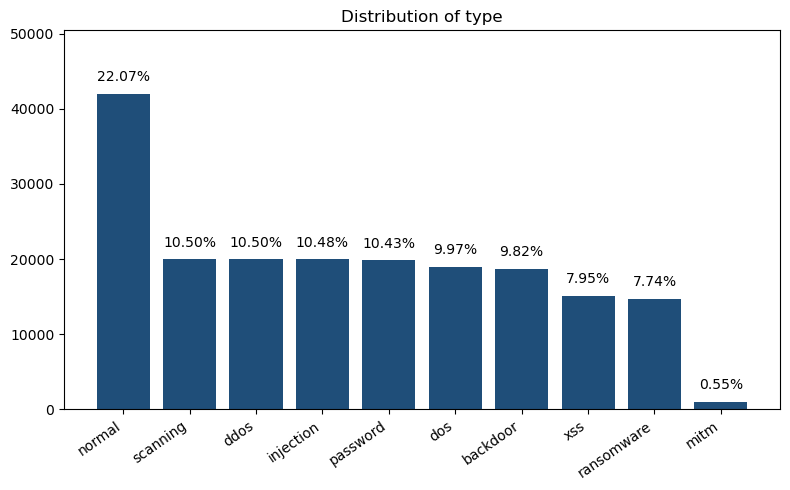

In [9]:
viz.target_distribution(label_column=multiclass_target)


#### 3.3. Numerical Data

Histogram

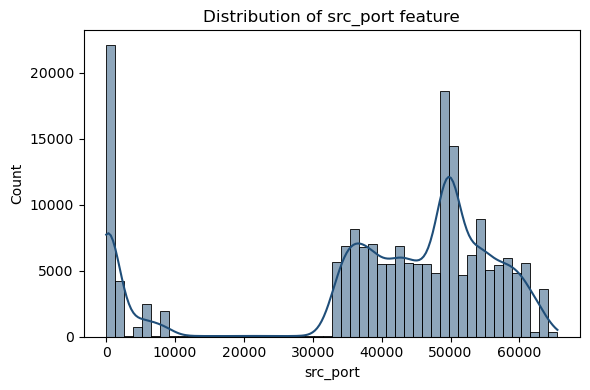

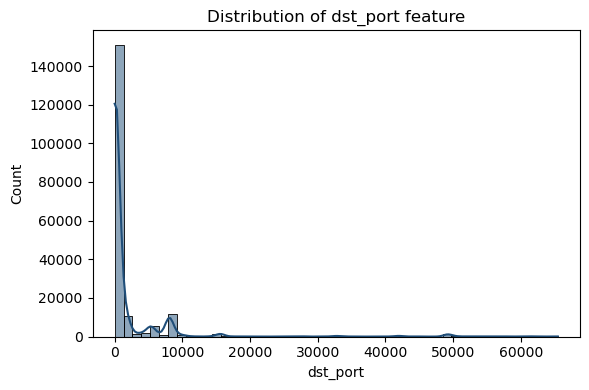

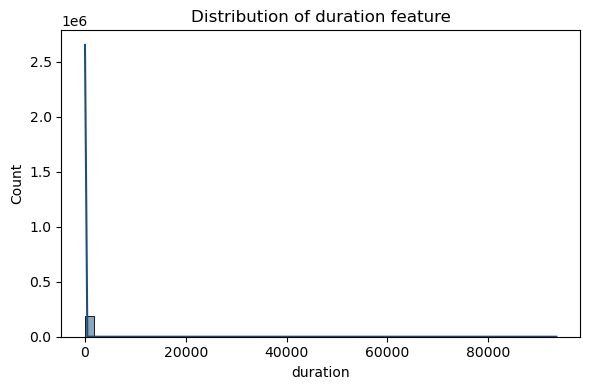

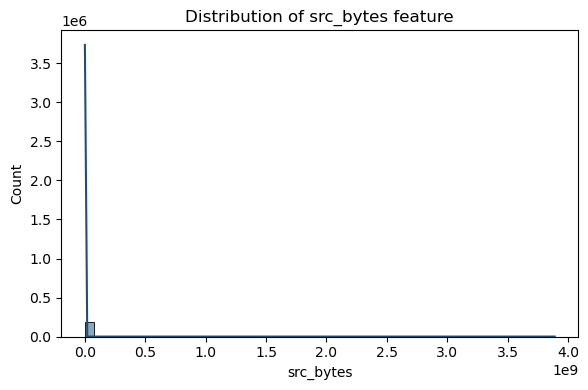

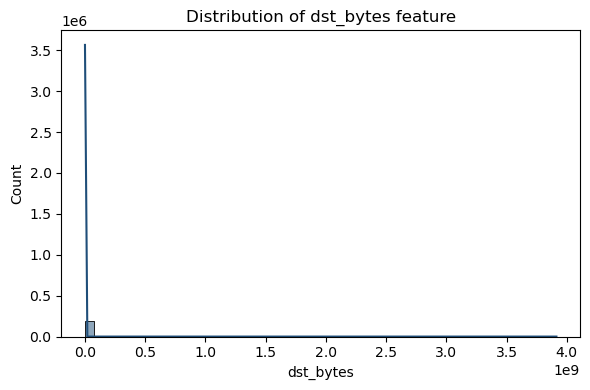

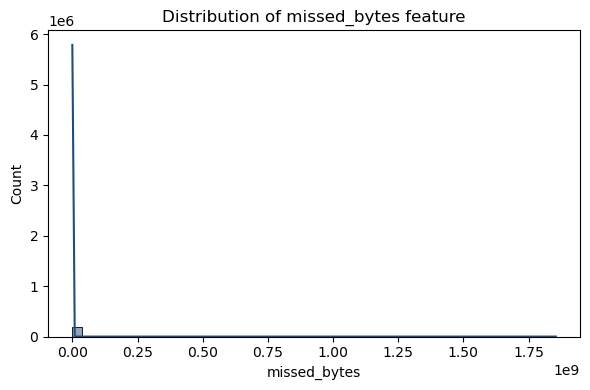

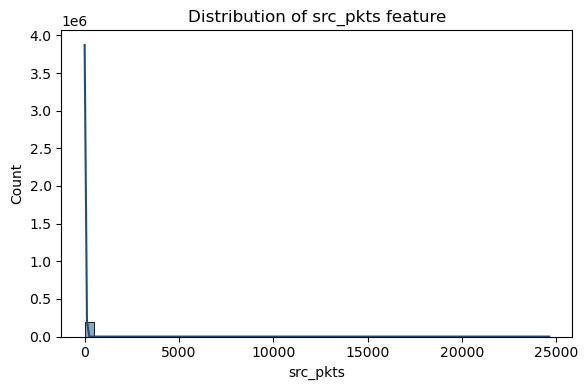

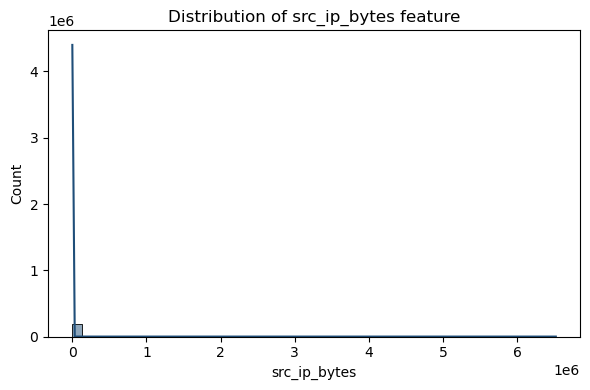

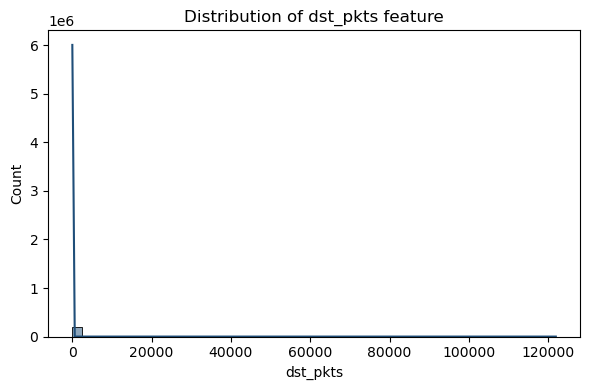

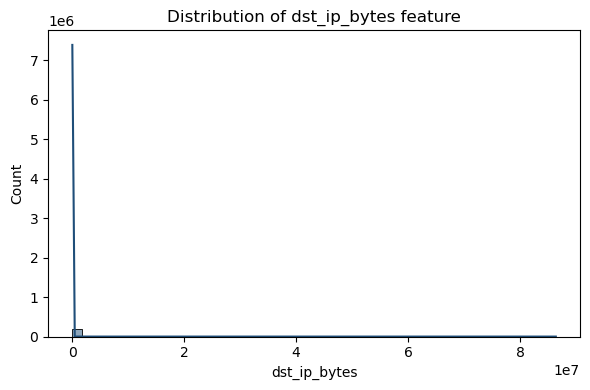

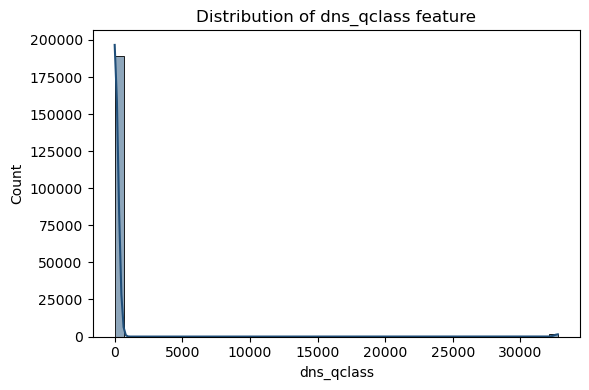

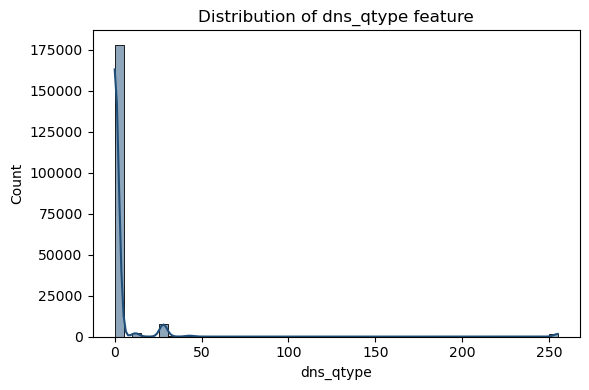

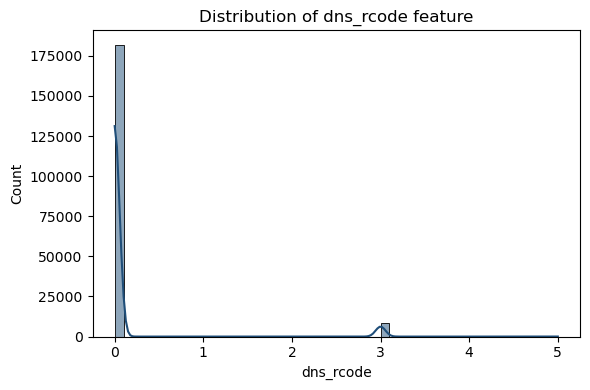

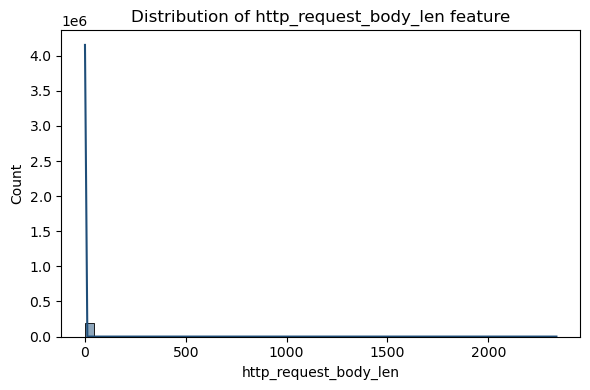

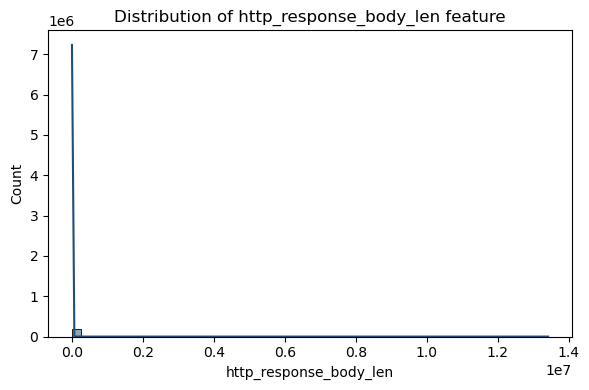

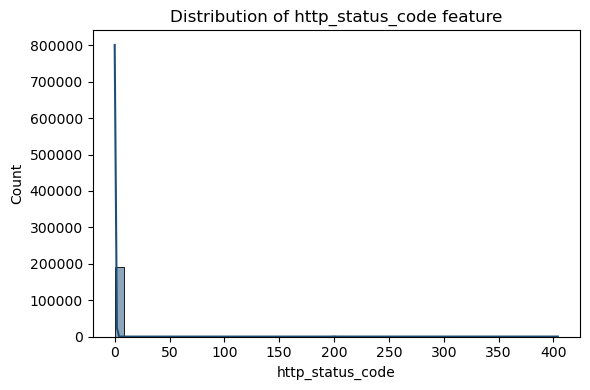

In [10]:
viz.numeric_distribution()


Boxplot

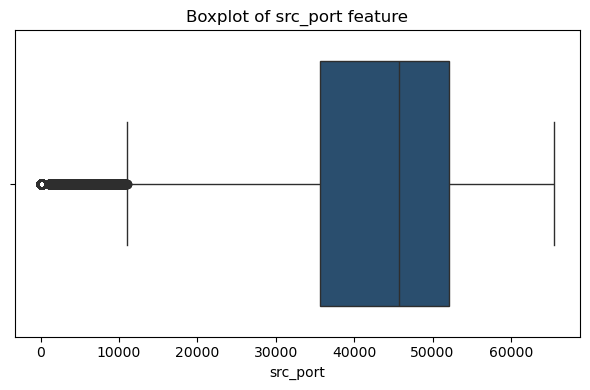

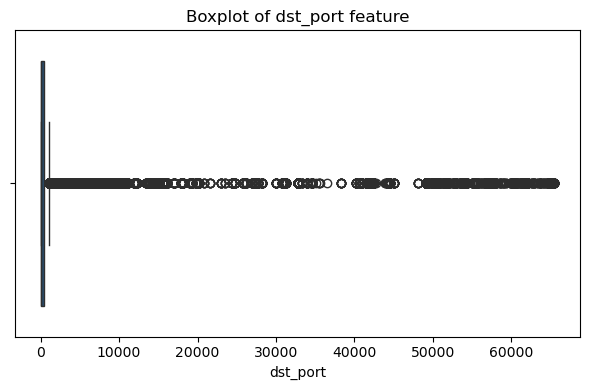

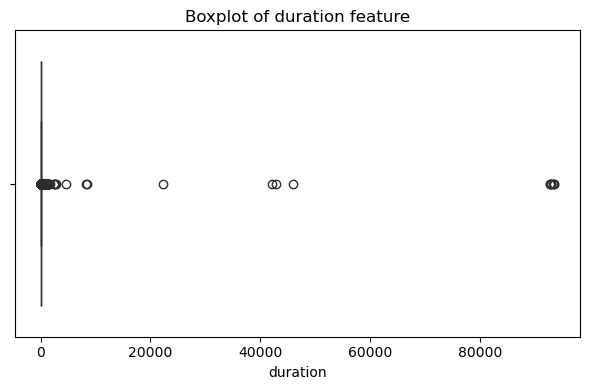

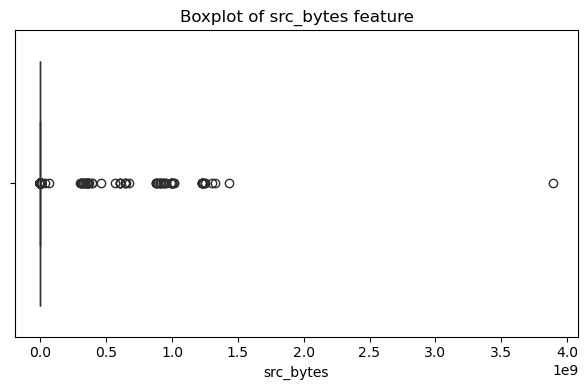

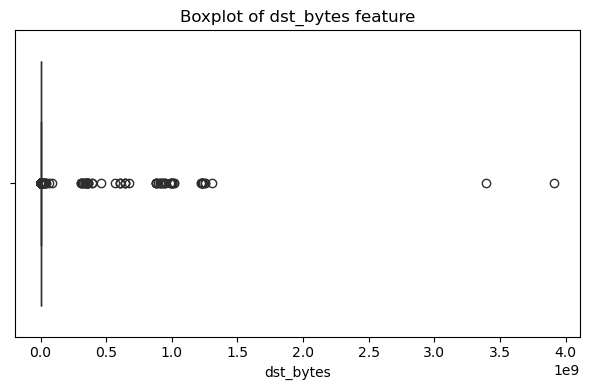

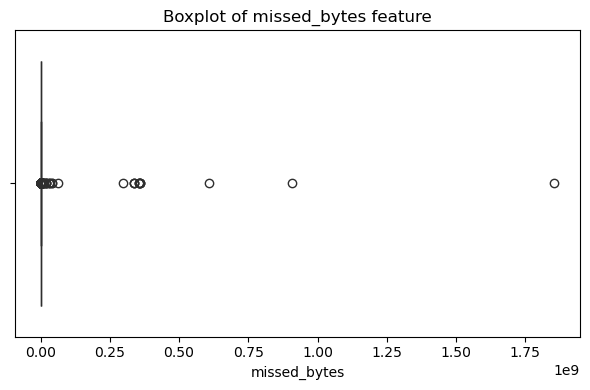

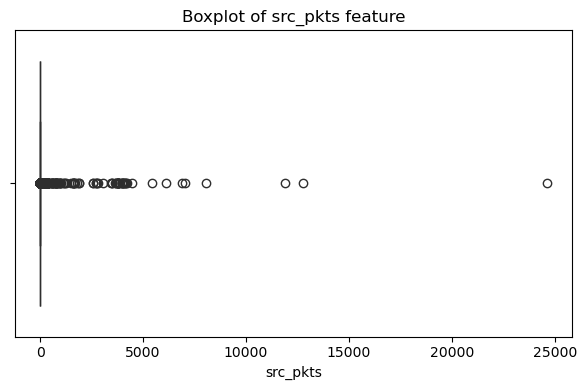

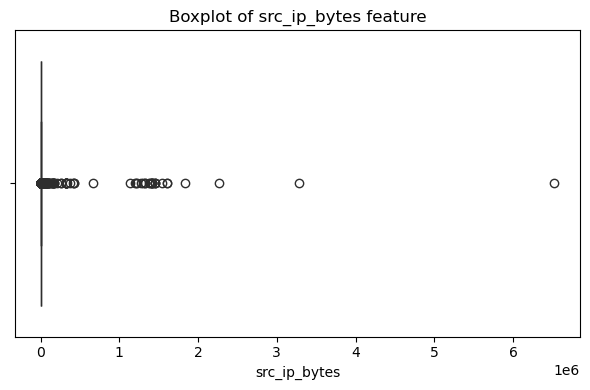

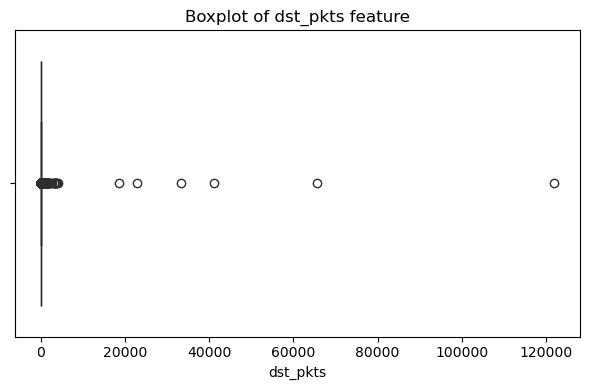

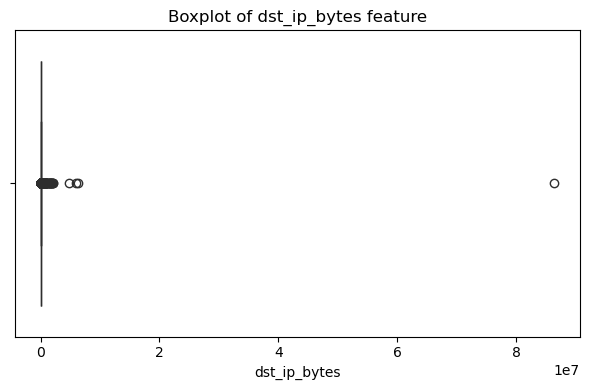

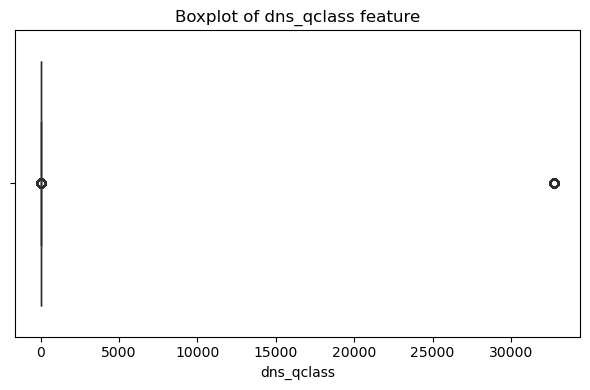

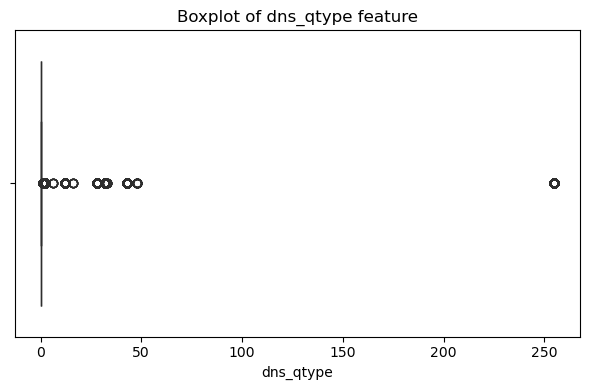

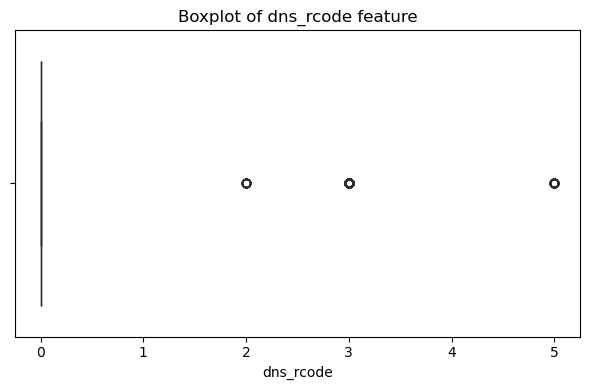

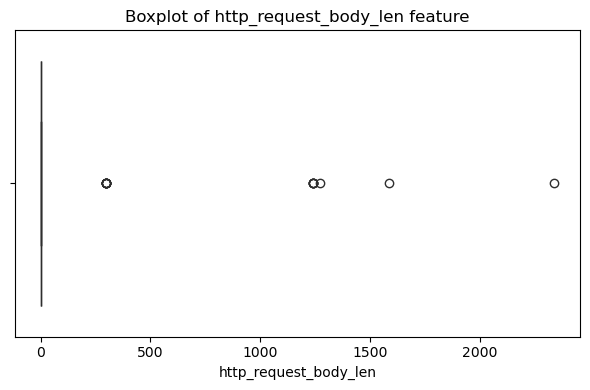

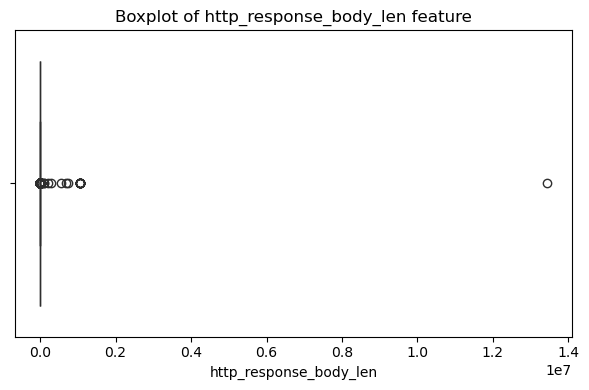

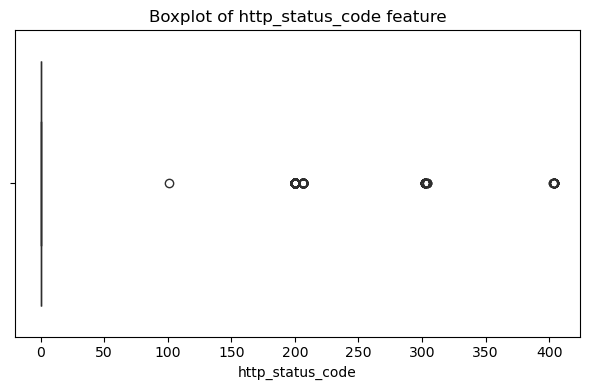

In [11]:
viz.boxplot()

#### 3.4. Categorical Data

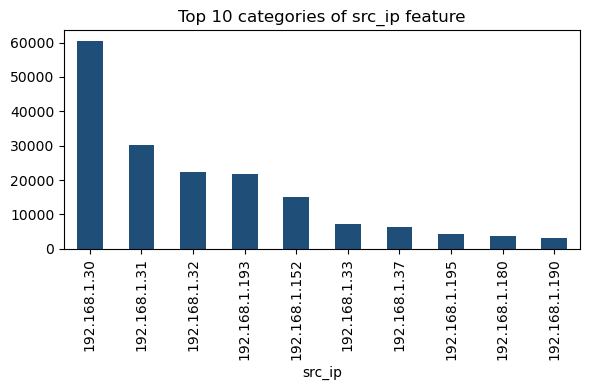

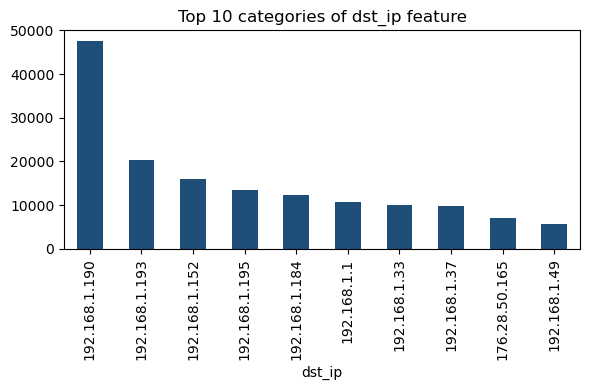

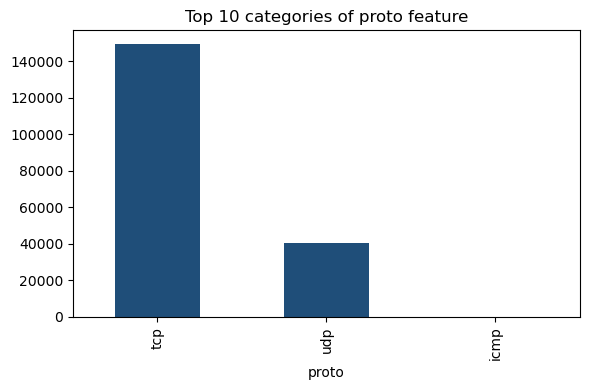

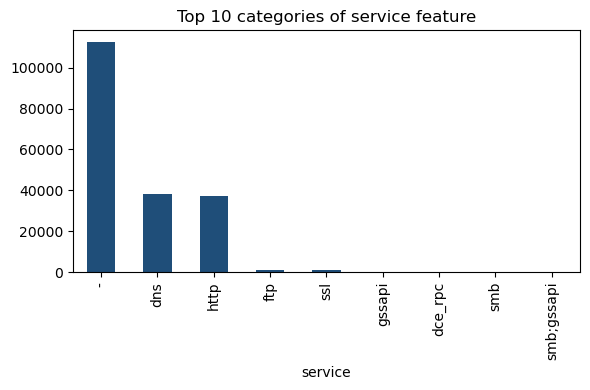

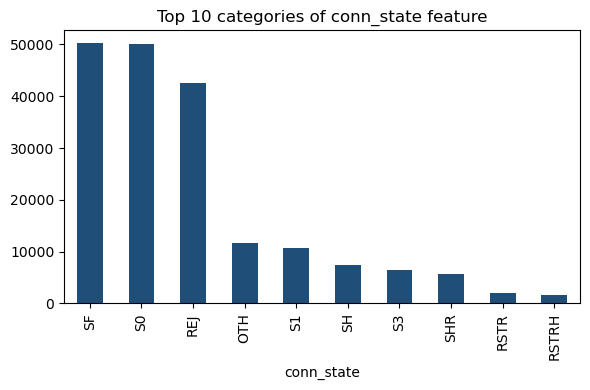

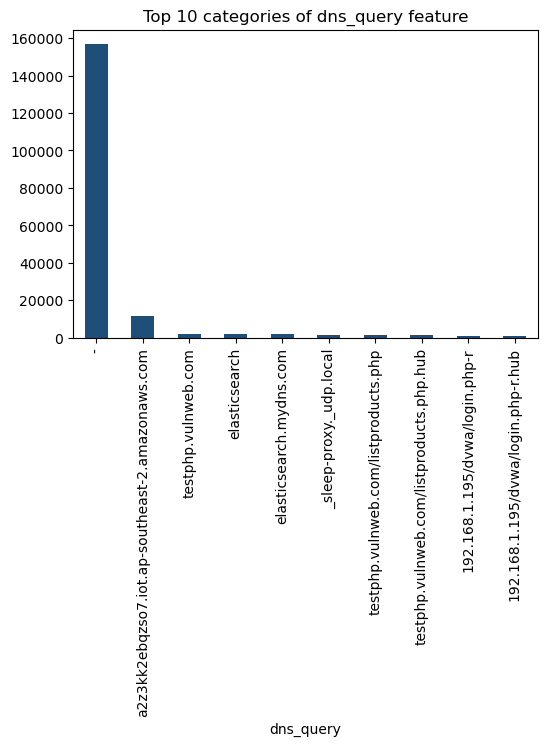

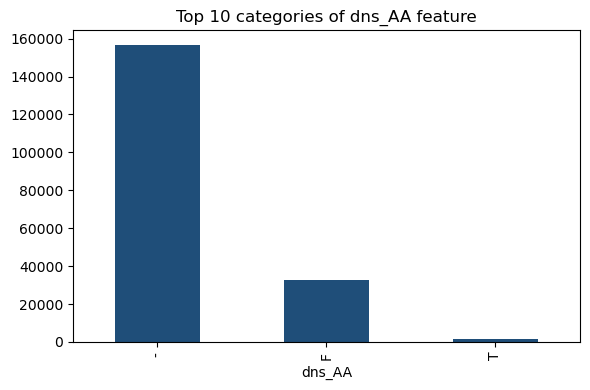

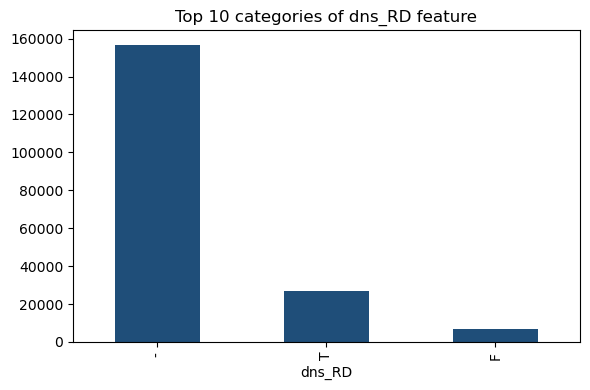

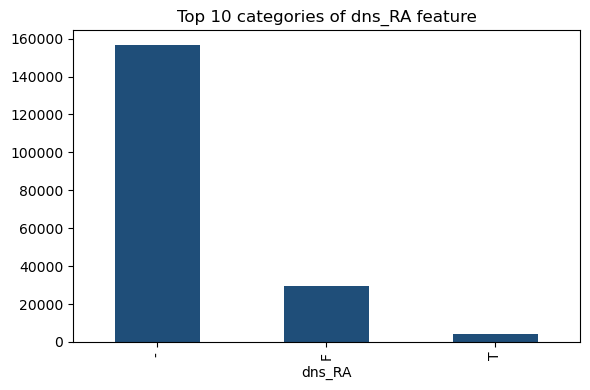

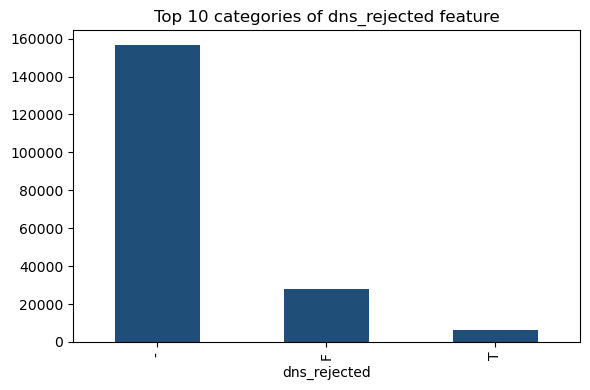

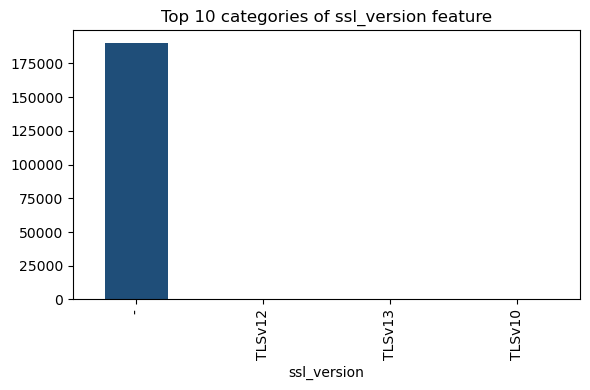

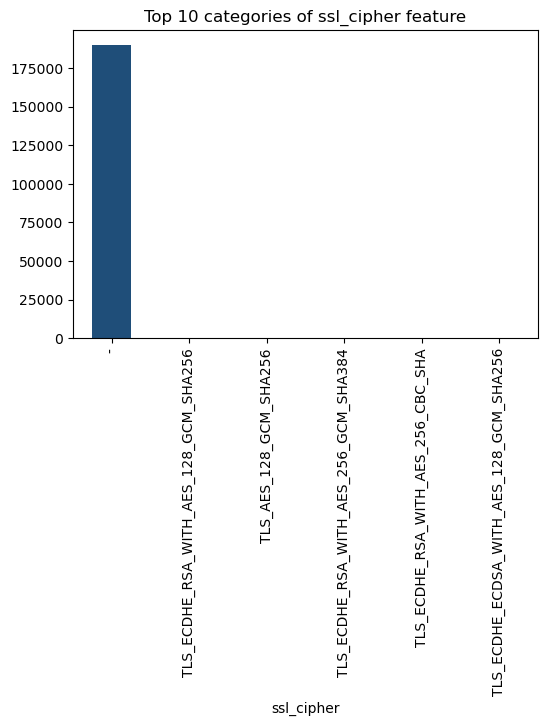

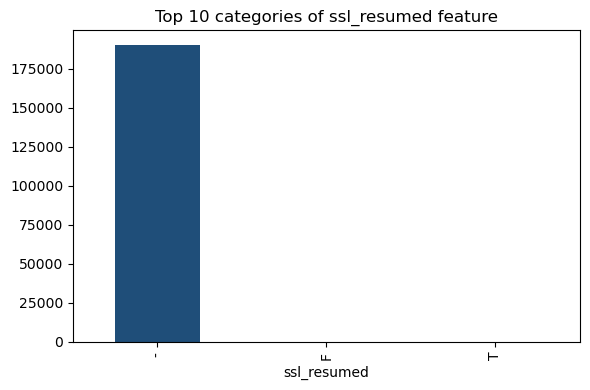

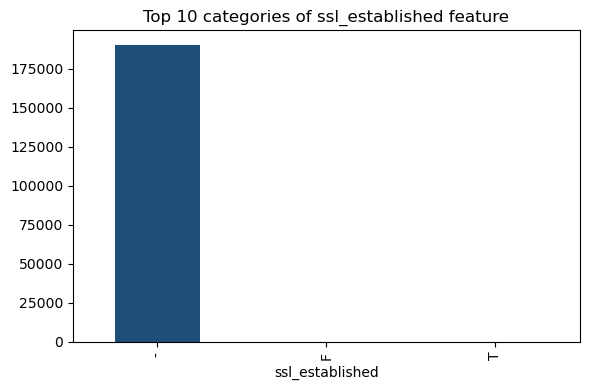

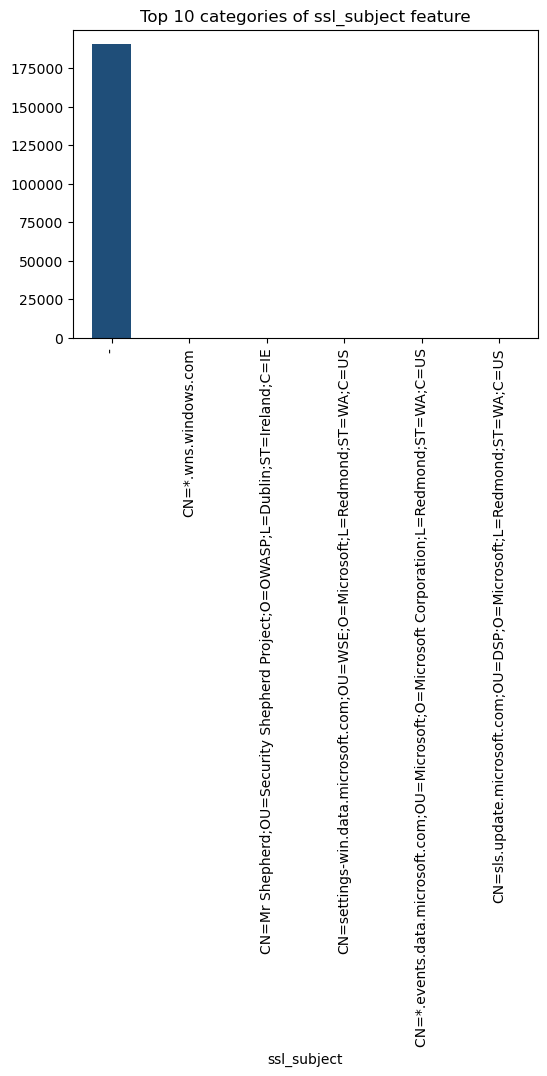

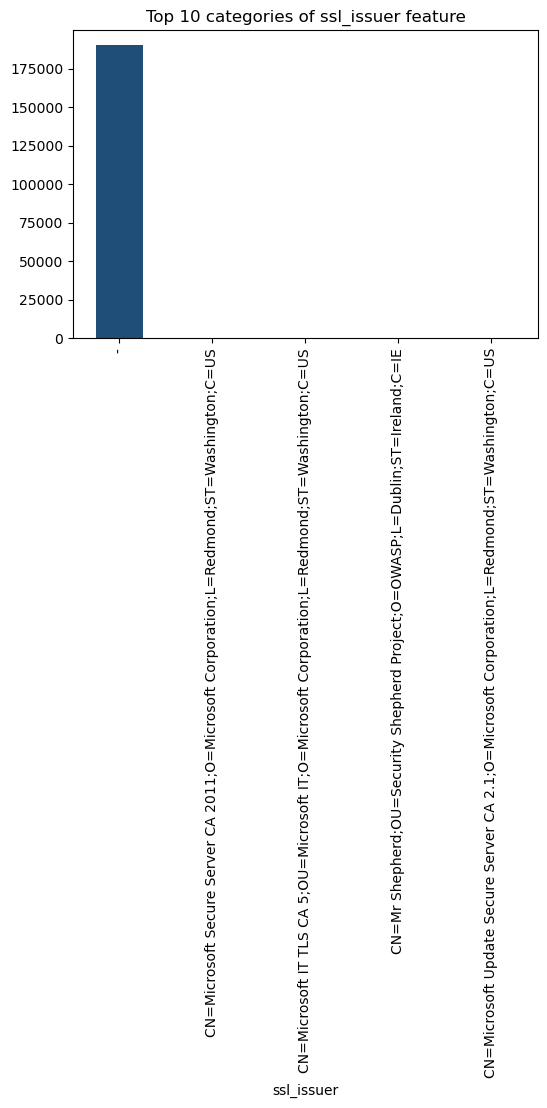

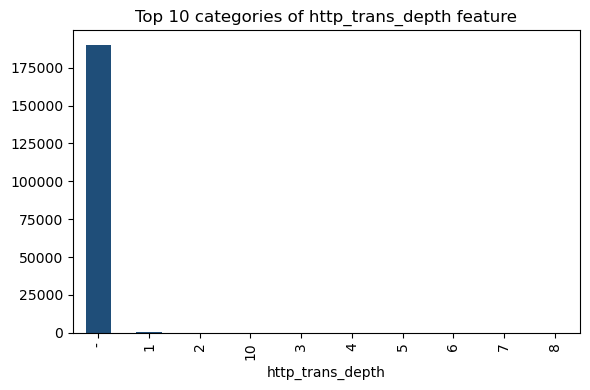

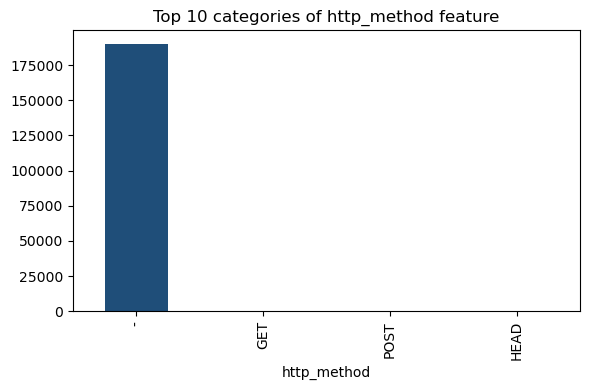

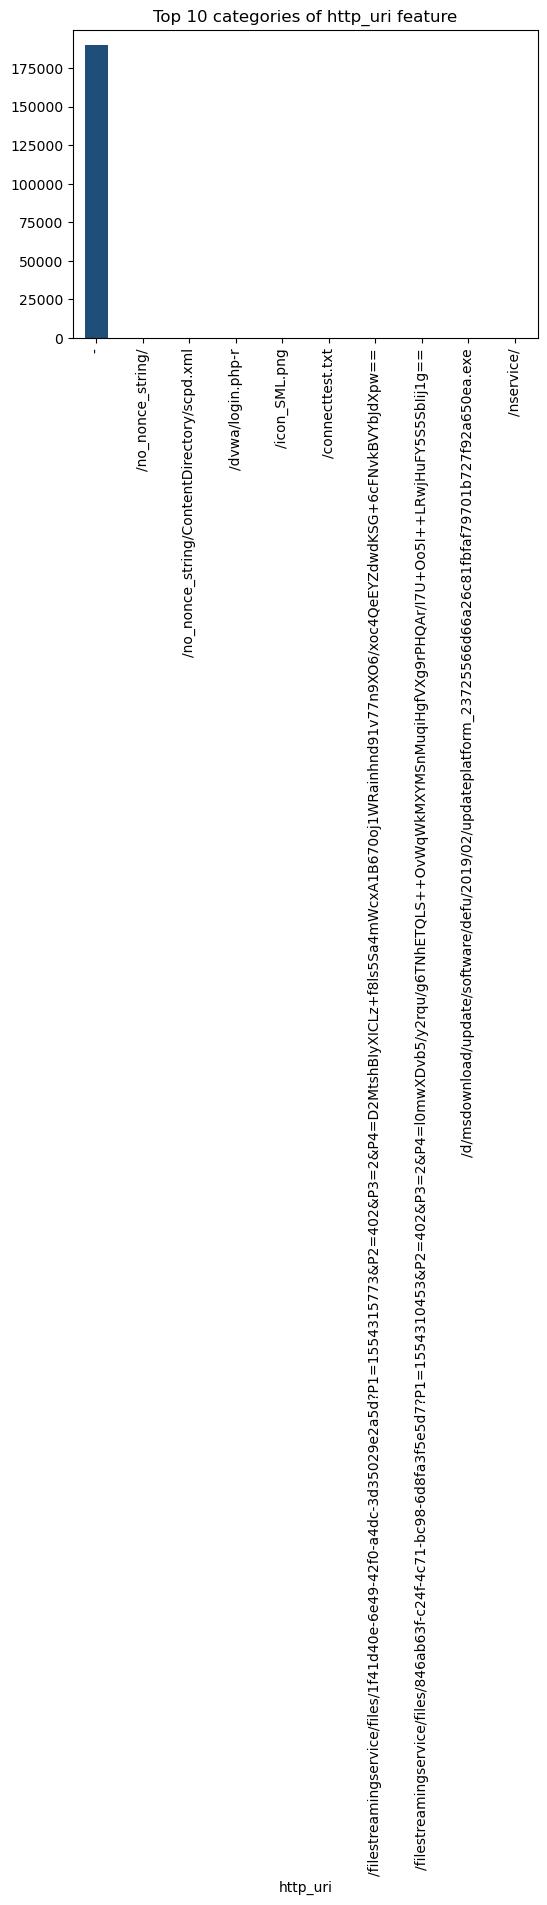

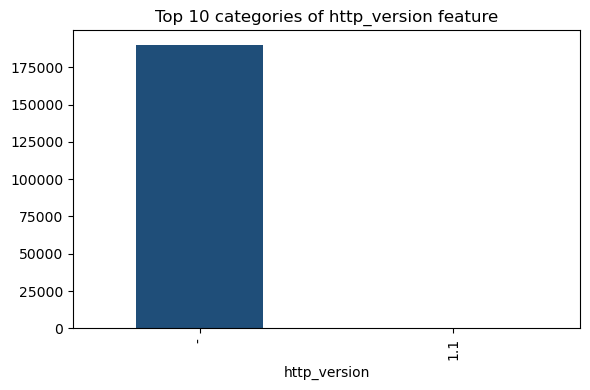

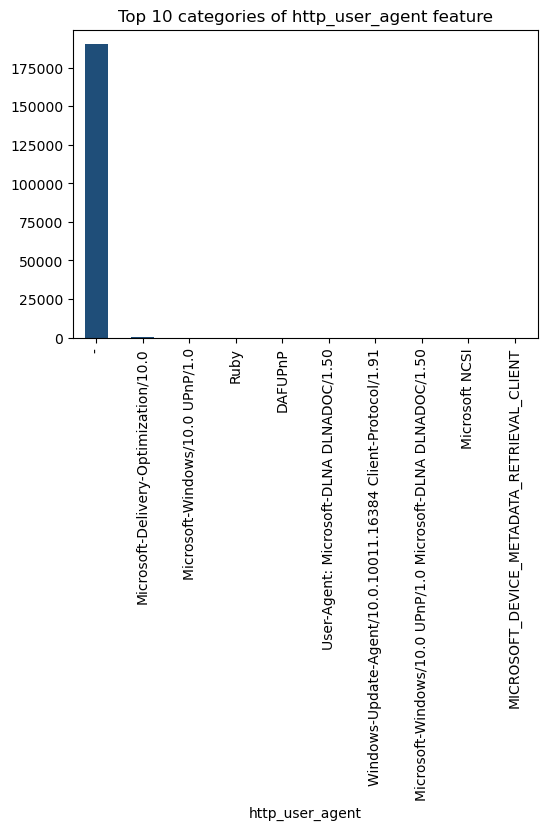

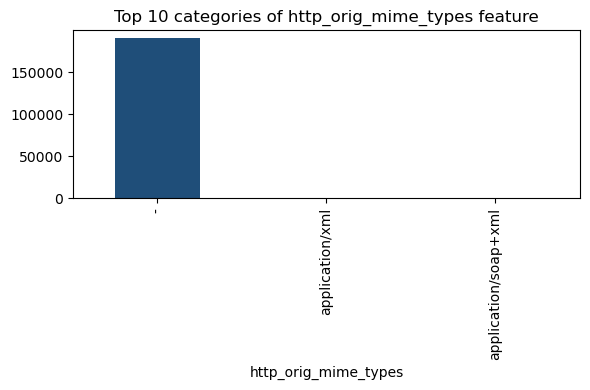

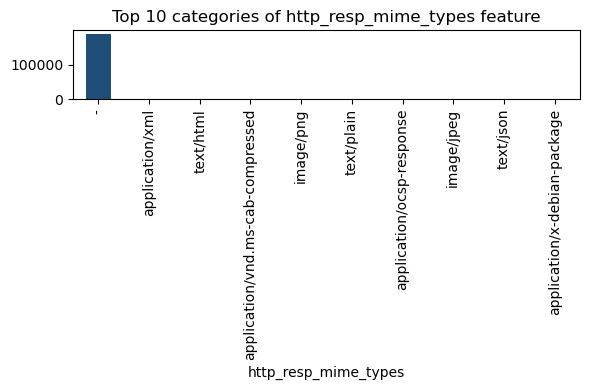

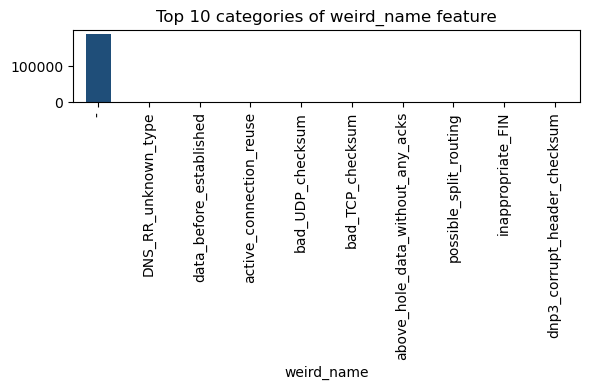

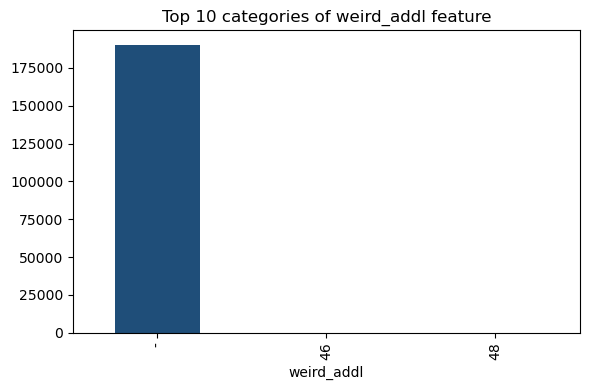

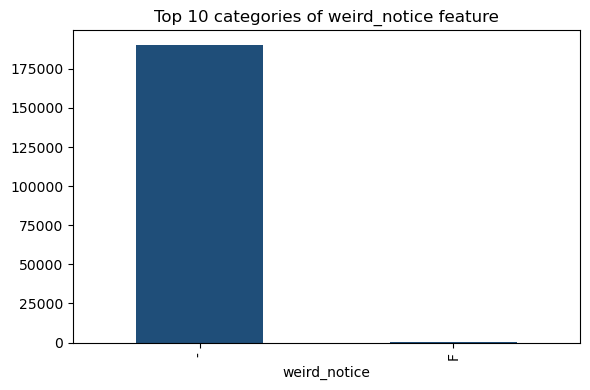

In [12]:
viz.categorical_distribution()

### 4. Preprocessing

#### 4.1. Binary class

In [5]:
preprocessor_BC = Preprocessor(
    target_column=binary_target,
    all_target_columns=all_target_columns,
    columns_to_drop=columns_to_drop,
    categorical_missing_token=categorical_missing_token,
    numeric_imputation_strategy=numeric_imputation_strategy,
    categorical_imputation_strategy=categorical_imputation_strategy
)

df_BC = preprocessor_BC.prepare_features(df)

X_BC = df_BC.drop(columns=[binary_target]).reset_index(drop=True)
y_BC = df_BC[binary_target].reset_index(drop=True)


['type'] target column eliminated
['src_ip', 'src_port', 'dst_ip', 'dst_port', 'dns_query', 'ssl_subject', 'ssl_issuer', 'http_uri', 'http_user_agent'] columns eliminated


#### 4.2. Multiclass

In [6]:
preprocessor_MC = Preprocessor(
    target_column=multiclass_target,
    all_target_columns=all_target_columns,
    columns_to_drop=columns_to_drop,
    categorical_missing_token=categorical_missing_token,
    numeric_imputation_strategy=numeric_imputation_strategy,
    categorical_imputation_strategy=categorical_imputation_strategy
)

df_MC = preprocessor_MC.prepare_features(df)

X_MC = df_MC.drop(columns=[multiclass_target]).reset_index(drop=True)
y_MC = df_MC[multiclass_target].reset_index(drop=True)


['label'] target column eliminated
['src_ip', 'src_port', 'dst_ip', 'dst_port', 'dns_query', 'ssl_subject', 'ssl_issuer', 'http_uri', 'http_user_agent'] columns eliminated


### 5. Feature Selection

#### 5.1. Binary class

In [7]:
mi_BC = MutualInformation(
    threshold=0.05,
    random_state=random_state
)


#### 5.2. Multiclass

In [8]:
mi_MC = MutualInformation(
    threshold=0.05,
    random_state=random_state
)


### 6. Train the models

#### 6.1. Binary class

In [9]:
# Models with default parameters
models_BC = ensemble_models(task_type="binary", random_state=random_state)
models_BC


{'RandomForest': RandomForestClassifier(random_state=80),
 'ExtraTrees': ExtraTreesClassifier(random_state=80),
 'LightGBM': LGBMClassifier(random_state=80, verbosity=-1),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, ...)}

X_train shape: (152379, 33)
y_train shape: (152379,)
X_test shape: (38095, 33)
y_test shape: (38095,)
14 numeric features: ['duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'http_request_body_len', 'http_response_body_len', 'http_status_code']
19 categorical features: ['proto', 'service', 'conn_state', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'http_trans_depth', 'http_method', 'http_version', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice']
Total features after preprocessing: 111
Mutual Information selected 24 features: ['src_ip_bytes', 'dst_ip_bytes', 'proto_tcp', 'src_bytes', 'proto_udp', 'duration', 'service_dns', 'dns_rejected_F', 'src_pkts', 'dns_rejected_Missing', 'dns_AA_Missing', 'dns_RA_Missing', 'dns_RD_Missing', 'dns_qtype', 'dns_RA_F', 'conn_state_S0', 'dst_bytes', 

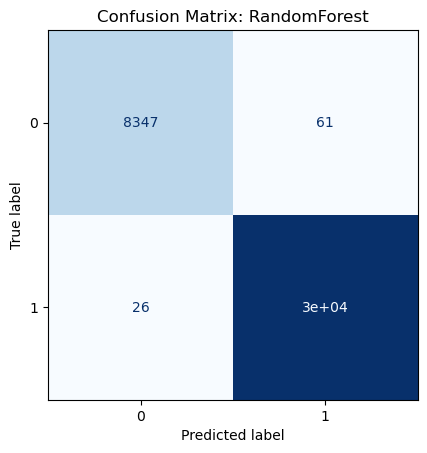


Running model: ExtraTrees


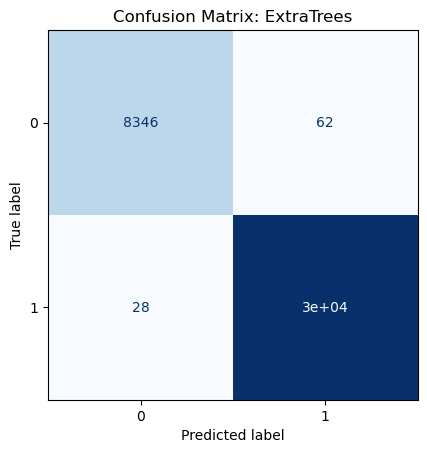


Running model: LightGBM


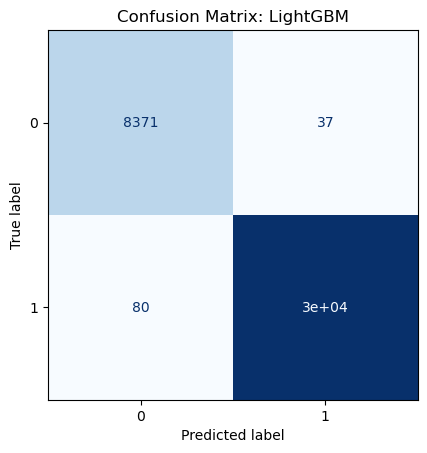


Running model: XGBoost


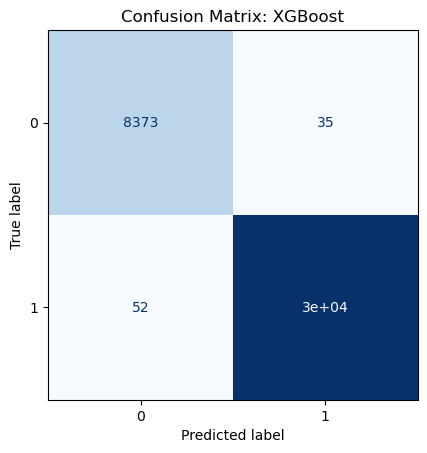

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,training_time_s,inference_time_per_sample_ms
0,RandomForest,0.999508,0.997716,0.999697,0.997948,0.999672,0.999124,0.999684,0.998536,7.303314,0.004781
1,ExtraTrees,0.999508,0.997637,0.999697,0.997914,0.999672,0.999057,0.999684,0.998485,5.544189,0.007687
2,LightGBM,0.997414,0.996929,0.999325,0.998752,0.997356,0.997305,0.998339,0.998028,1.747618,0.000630
3,XGBoost,0.998405,0.997716,0.999671,0.998820,0.998282,0.998248,0.998976,0.998534,0.371490,0.000286


In [10]:
runner_BC = ModelEvaluator(
    test_size=0.2,
    random_state=random_state,
    task_type="binary",
    split_strategy="stratified"
)

results_BC = runner_BC.run(
    models=models_BC,
    preprocessor=preprocessor_BC,
    X=X_BC,
    y=y_BC,
    feature_selector=mi_BC
)

results_BC


#### 6.2. Multiclass

In [11]:
models_MC = ensemble_models(task_type="multiclass", random_state=random_state)
models_MC


{'RandomForest': RandomForestClassifier(random_state=80),
 'ExtraTrees': ExtraTreesClassifier(random_state=80),
 'LightGBM': LGBMClassifier(random_state=80, verbosity=-1),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='mlogloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, ...)}

{'backdoor': 0, 'ddos': 1, 'dos': 2, 'injection': 3, 'mitm': 4, 'normal': 5, 'password': 6, 'ransomware': 7, 'scanning': 8, 'xss': 9}
X_train shape: (152379, 33)
y_train shape: (152379,)
X_test shape: (38095, 33)
y_test shape: (38095,)
14 numeric features: ['duration', 'src_bytes', 'dst_bytes', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'http_request_body_len', 'http_response_body_len', 'http_status_code']
19 categorical features: ['proto', 'service', 'conn_state', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'http_trans_depth', 'http_method', 'http_version', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice']
Total features after preprocessing: 110
Mutual Information selected 32 features: ['src_ip_bytes', 'dst_ip_bytes', 'duration', 'src_bytes', 'dst_bytes', 'dst_pkts', 'src_pkts', 'conn_state_REJ', 'conn_state_S0'

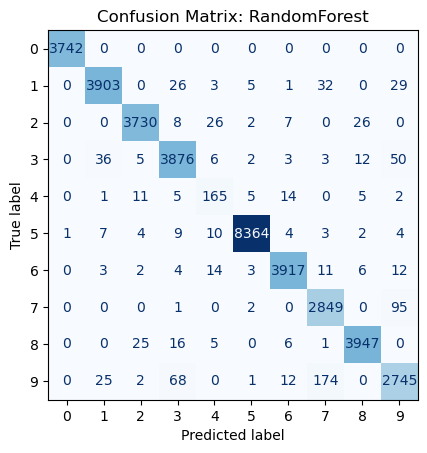


Running model: ExtraTrees


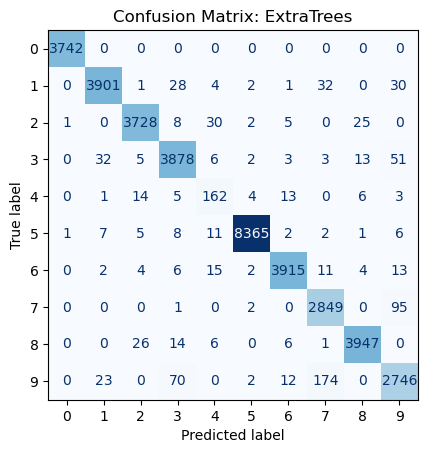


Running model: LightGBM


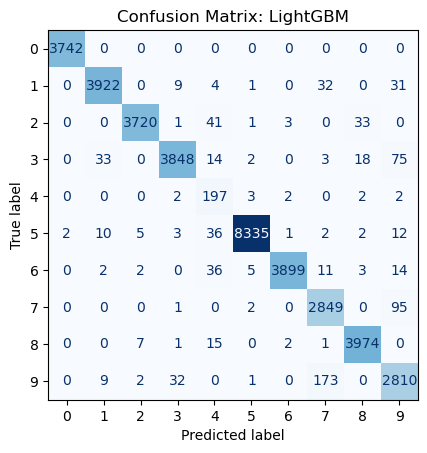


Running model: XGBoost


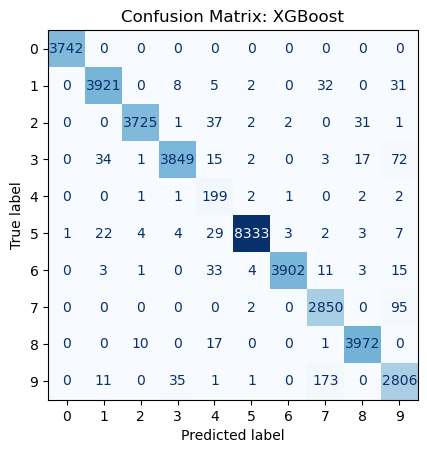

,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,training_time_s,inference_time_per_sample_ms
0,RandomForest,0.990445,0.977504,0.986902,0.948977,0.988878,0.956305,0.987768,0.952402,9.540730,0.010139
1,ExtraTrees,0.990451,0.977372,0.986894,0.946137,0.988899,0.954805,0.987777,0.950154,8.936244,0.013774
2,LightGBM,0.983475,0.979026,0.955117,0.937750,0.982363,0.973225,0.966375,0.950849,2.429471,0.007904
3,XGBoost,0.982714,0.979105,0.954367,0.939422,0.981604,0.974222,0.965625,0.952464,3.399048,0.001884


In [12]:
runner_MC = ModelEvaluator(
    test_size=0.2,
    random_state=random_state,
    task_type="multiclass",
    split_strategy="stratified"
)

results_MC = runner_MC.run(
    models=models_MC,
    preprocessor=preprocessor_MC,
    X=X_MC,
    y=y_MC,
    feature_selector=mi_MC
)

results_MC


### 7. TreeSHAP

#### 7.1.2. Multiclass

In [13]:
explainer_MC = SHAPTreeExplainer(task_type="multiclass", n_samples=3000, random_state=random_state) 

RandomForest

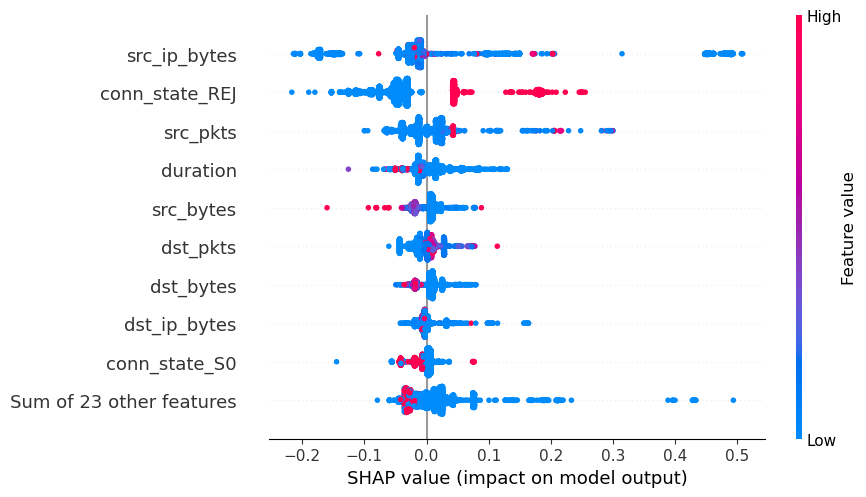

In [14]:
model_MC_rf, X_train_MC_rf, y_train_MC_rf, X_test_MC_rf, y_test_MC_rf = (
    runner_MC.get_model_data("RandomForest")
)

explainer_MC.plot_beeswarm(model_MC_rf, X_test_MC_rf, class_index=2)

ExtraTrees

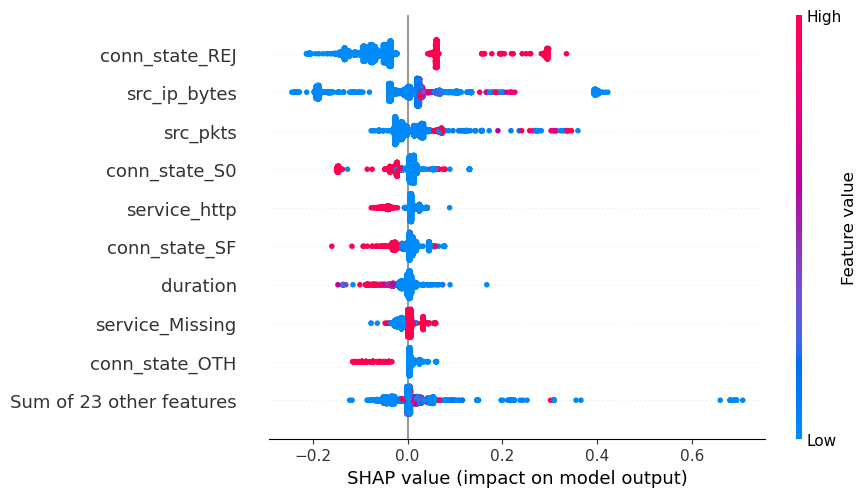

In [15]:
model_MC_et, X_train_MC_et, y_train_MC_et, X_test_MC_et, y_test_MC_et = (
    runner_MC.get_model_data("ExtraTrees")
)

explainer_MC.plot_beeswarm(model_MC_et, X_test_MC_et, class_index=2)

XGBoost

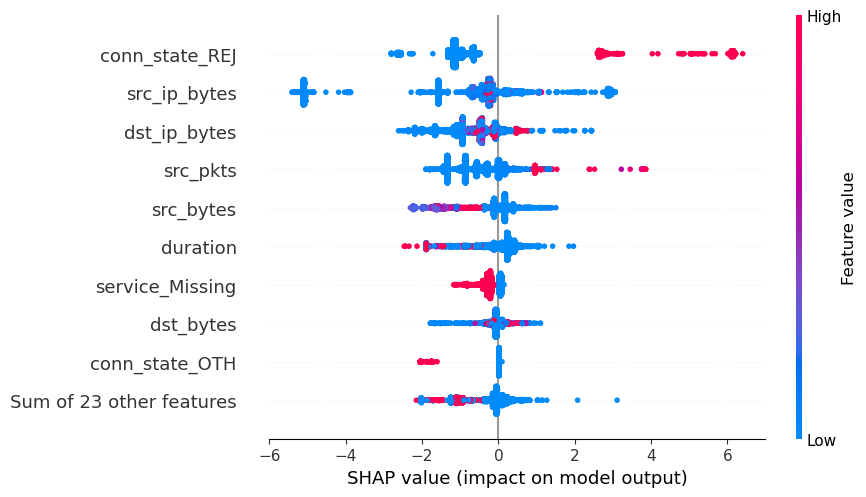

In [16]:
model_MC_xg, X_train_MC_xg, y_train_MC_xg, X_test_MC_xg, y_test_MC_xg = (
    runner_MC.get_model_data("XGBoost")
)

explainer_MC.plot_beeswarm(model_MC_xg, X_test_MC_xg, class_index=2)

LightGBM

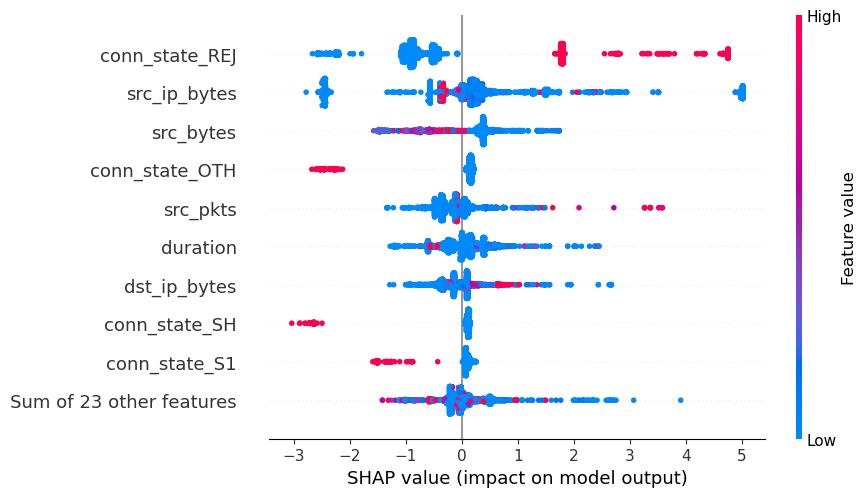

In [17]:
model_MC_lb, X_train_MC_lb, y_train_MC_lb, X_test_MC_lb, y_test_MC_lb = (
    runner_MC.get_model_data("LightGBM")
)

explainer_MC.plot_beeswarm(model_MC_lb, X_test_MC_lb, class_index=2)